# Data Augmentation To Address Overfitting In Flower Classification CNN

In this notebook, we will develop a Convolutional Neural Network (CNN) to classify flower images. We will also examine how the model can overfit the training data and explore how data augmentation can help reduce this issue. Data augmentation involves creating additional training examples from the existing dataset by applying transformations such as zooming, rotation, and contrast adjustment.

Acknowledgment: This work was inspired by the official TensorFlow image classification tutorial, which I used as a reference and then simplified with several modifications.
link: https://www.tensorflow.org/tutorials/images/classification
In the image below, four additional training samples have been created from a single original image by applying different transformations.


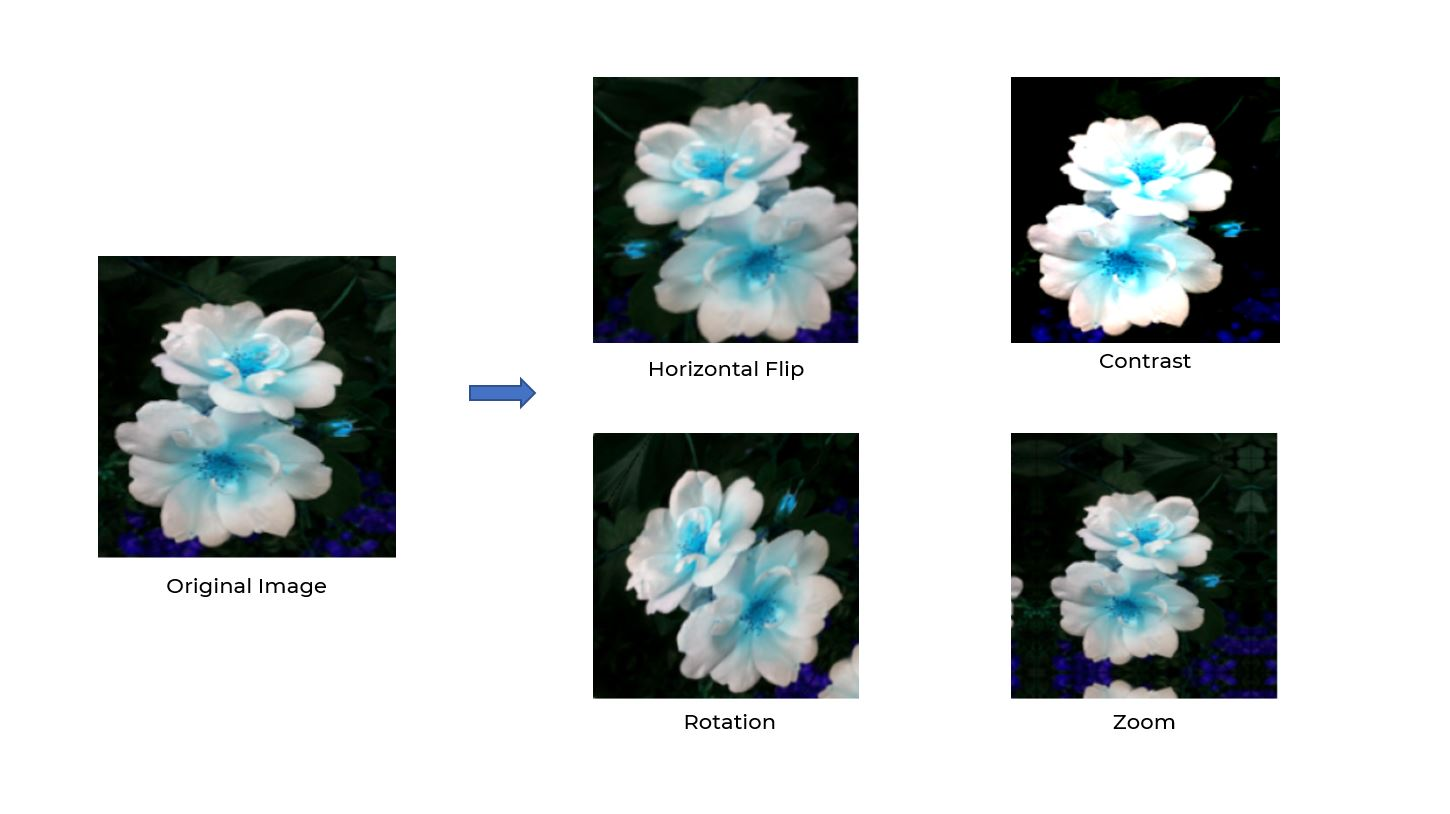

# Importing Dependencies and Library

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf
import pandas as pd
import pathlib

from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Downloading the Dataset of flowers

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
data_dir

'./datasets/flower_photos'

In [4]:
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [5]:
list(data_dir.glob('*/*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/sunflowers/5967283168_90dd4daf28_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/sunflowers/13096076565_72c2c60875_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/sunflowers/2723995667_31f32294b4.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/sunflowers/5927432662_3ffd2461c2_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/sunflowers/5970301989_fe3a68aac8_m.jpg')]

In [6]:
image_count = len(list(data_dir.glob('*/*/*.jpg')))
print(image_count)

3670


In [9]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[]

In [11]:
list(data_dir.glob('*/*'))[:10]

[PosixPath('datasets/flower_photos/flower_photos/sunflowers'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion'),
 PosixPath('datasets/flower_photos/flower_photos/tulips'),
 PosixPath('datasets/flower_photos/flower_photos/LICENSE.txt'),
 PosixPath('datasets/flower_photos/flower_photos/roses'),
 PosixPath('datasets/flower_photos/flower_photos/daisy')]

In [12]:
list(data_dir.glob('*/*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/sunflowers/5967283168_90dd4daf28_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/sunflowers/13096076565_72c2c60875_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/sunflowers/2723995667_31f32294b4.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/sunflowers/5927432662_3ffd2461c2_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/sunflowers/5970301989_fe3a68aac8_m.jpg')]

In [8]:
roses = list(data_dir.glob('*/roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/3630246240_4fee9a33db.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2501297526_cbd66a3f7e_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3494252600_29f26e3ff0_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16670921315_0fc48d7ab2_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3526860692_4c551191b1_m.jpg')]

In [13]:
data_dir = data_dir / 'flower_photos'

In [14]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/3630246240_4fee9a33db.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2501297526_cbd66a3f7e_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3494252600_29f26e3ff0_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16670921315_0fc48d7ab2_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3526860692_4c551191b1_m.jpg')]

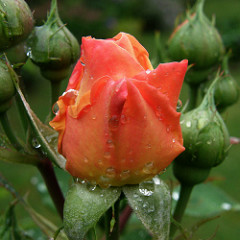

In [15]:
PIL.Image.open(str(roses[1]))

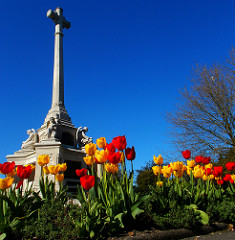

In [16]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

# Read flowers images from disk into numpy array using opencv

In [17]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [18]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [19]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/3630246240_4fee9a33db.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2501297526_cbd66a3f7e_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3494252600_29f26e3ff0_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16670921315_0fc48d7ab2_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3526860692_4c551191b1_m.jpg')]

In [20]:
str(flowers_images_dict['roses'][0])

'datasets/flower_photos/flower_photos/roses/3630246240_4fee9a33db.jpg'

In [21]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [22]:
img.shape

(333, 500, 3)

In [23]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [24]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])



In [25]:
X = np.array(X)
y = np.array(y)

# Train test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Preprocessing: scale images

In [27]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

# Build Convolutional neural network and train it

In [28]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.4597 - loss: 1.3166
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6137 - loss: 0.9952
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6879 - loss: 0.8200
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7700 - loss: 0.6145
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8452 - loss: 0.4379
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9106 - loss: 0.2664
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9571 - loss: 0.1525
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9724 - loss: 0.1102
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9767 - loss: 0.0754
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9829 - loss: 0.0578
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9898 - loss: 0.0500
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy:

In [29]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6645 - loss: 2.3159


[2.315927743911743, 0.6644880175590515]

## Here we see that while train accuracy is very high (99.96%), the test accuracy is significantly low (66.45%) indicating overfitting. Let's make some predictions before we use data augmentation to address overfitting

In [30]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


array([[ -8.276527  ,  12.265601  ,  15.308844  ,   8.303051  ,
         -9.063358  ],
       [ 23.752388  , -10.728047  , -15.694029  , -16.238634  ,
          9.438517  ],
       [  2.2309506 ,   0.9587333 ,   4.430635  ,  -5.3129034 ,
         -1.738232  ],
       ...,
       [ -0.57646483,  -7.474539  ,  10.48707   ,  28.317719  ,
          3.5436153 ],
       [ 12.667358  ,   5.676108  ,  -4.846988  , -11.451343  ,
         -0.90724784],
       [  0.12847215, -13.541034  ,   8.993866  ,  30.85614   ,
          9.298002  ]], dtype=float32)

In [31]:
score = tf.nn.softmax(predictions[0])

In [32]:
np.argmax(score)

np.int64(2)

In [33]:
y_test[0]


np.int64(1)

# Improve test accuracy using data augmentation

In [37]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## original image

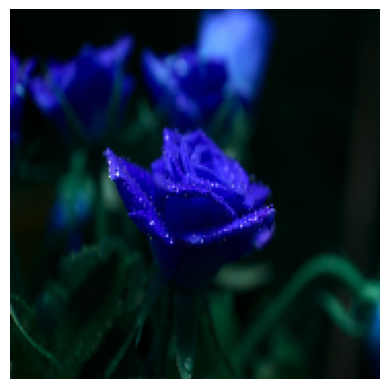

In [36]:
plt.axis('off')
plt.imshow(X[0])

## Newly generated training sample using data augmentation

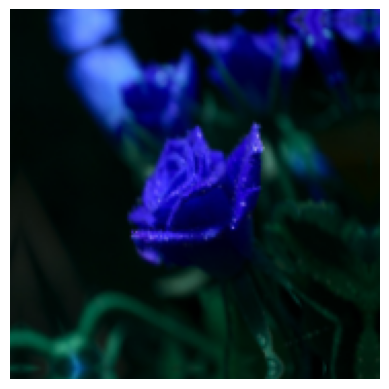

In [40]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

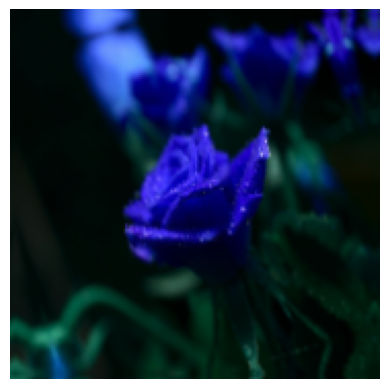

In [42]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

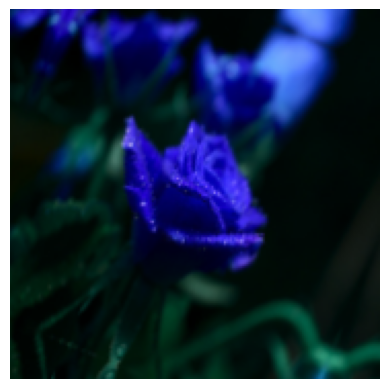

In [43]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

# Train the model using data augmentation and a drop out layer

In [41]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.4480 - loss: 1.3018
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5927 - loss: 1.0419
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6555 - loss: 0.9205
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6588 - loss: 0.8772
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6930 - loss: 0.8018
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7024 - loss: 0.7859
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7122 - loss: 0.7380
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7366 - loss: 0.7031
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7525 - loss: 0.6638
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7533 - loss: 0.6367
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7674 - loss: 0.6054
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy:

In [44]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7636 - loss: 0.9765


[0.9764994978904724, 0.7636165618896484]

## Here we can see that by using data augmentation and drop out layer the accuracy of test set predictions is increased to 76.36%.